In [1]:
include("src/WaveSolverCUDA.jl")
using .WaveSolverCUDA

In [2]:
using JLD2, ImageFiltering, PyPlot, LinearAlgebra

In [ ]:
A = randn(3,4,5)

println(norm(A)^2)

val = 0
for i in 1:5
    val += norm(A[:,:,i])^2
end

println(val)

36.04305602715371
36.04305602715371


Fatal Python error: PyThreadState_Get: the function must be called with the GIL held, after Python initialization and before Python finalization, but the GIL is released (the current Python thread state is NULL)
Python runtime state: initialized

Thread 0x000076b16cb44140 (most recent call first):
  <no Python frame>

[13500] signal 6 (-6): Aborted
in expression starting at none:1
pthread_kill at /lib/x86_64-linux-gnu/libc.so.6 (unknown line)
gsignal at /lib/x86_64-linux-gnu/libc.so.6 (unknown line)
abort at /lib/x86_64-linux-gnu/libc.so.6 (unknown line)


: 

In [4]:
Nx, Ny = 201, 201
dx, dy = 5, 5
Nt = 1500
Fs = 1000
dt = 1/Fs
t = range(0, (Nt-1)*dt, Nt)
pml_len = 30
pml_coef = 100

c = 1000 .* ones(Nx, Ny)
c_true = copy(c)
c_true[85:115,50:80] .= 950
c_true[85:115,120:150] .= 1200
c = imfilter(c_true, Kernel.gaussian(15))
c = (c .- minimum(c)) ./ (maximum(c) - minimum(c)) * (maximum(c_true) - minimum(c_true)) .+ minimum(c_true)

source_num = 9
source_position = zeros(2,source_num)
for i = 1:source_num
    source_position[1,i] = 1
    source_position[2,i] = 1 + (i-1)*25
end
source_vals = zeros(Nt, source_num)
for i = 1:source_num
    # source_vals[:,i] = source_ricker(15,0.1,t) * 1e5
    source_vals[:,i] = source_ricker(10,0.1,t)
end

receiver_num = 101
receiver_position = zeros(2, receiver_num)
for i = 1:receiver_num
    receiver_position[1,i] = 201
    receiver_position[2,i] = (i-1)*2 + 1
end

CUDA.@time data_true = forward_acoustic_c(c_true, Nx, Ny, Nt, dx, dy, dt, source_num, source_position, source_vals, receiver_num, receiver_position, pml_len, pml_coef; blockx=16, blocky=16)
@save "temp_data/true_data.jld2" data_true

 12.966311 seconds (26.83 M CPU allocations: 1.383 GiB, 1.65% gc time) (18 GPU allocations: 8.366 MiB, 0.03% memmgmt time)


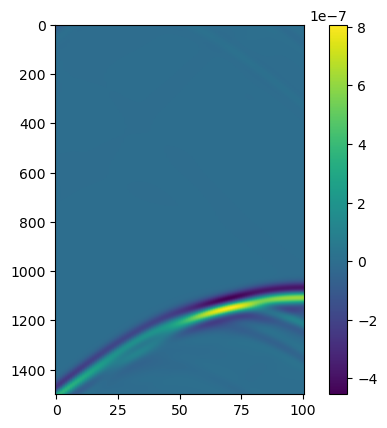

PyObject <matplotlib.colorbar.Colorbar object at 0x7c7940197b60>

In [5]:
close()
figure()
imshow(data_true[:,:,9], aspect=0.1)
colorbar()

In [6]:
include("src/prox.jl")

a = [950., 1000., 1200.]
b = [950., 1000., 1200.]
nu = 1e-4
# nu = 0
lamb = 3e3
iterMax = 30

x0 = copy(c)[:]
# @load "temp_data/level2/30.jld2"
# x0 = copy(x)[:]

eval_obj(x) = eval_obj_fwi(data_true, x, Nx, Ny, Nt, dx, dy, dt, source_num, source_position, source_vals, receiver_num, receiver_position, pml_len, pml_coef; blockx=16, blocky=16) + eval_theta(x, a, b, nu)

eval_grad(x) = eval_grad_fwi(data_true, x, Nx, Ny, Nt, dx, dy, dt, source_num, source_position, source_vals, receiver_num, receiver_position, pml_len, pml_coef; blockx=16, blocky=16)

eval_prox_op(v, lamb) = eval_prox_op(v, a, b, nu, lamb)

eval_prox_op (generic function with 3 methods)

In [7]:
_, grad = eval_grad(x0)
@save "temp_data/grad.jld2" grad

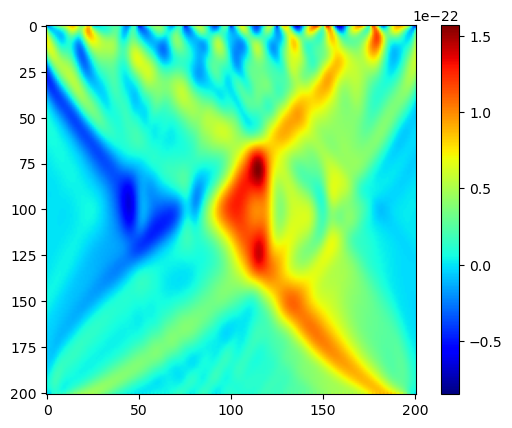

PyObject <matplotlib.colorbar.Colorbar object at 0x7c7925350690>

In [8]:
close()
figure()
imshow(reshape(grad, 201, 201), cmap="jet")
colorbar()

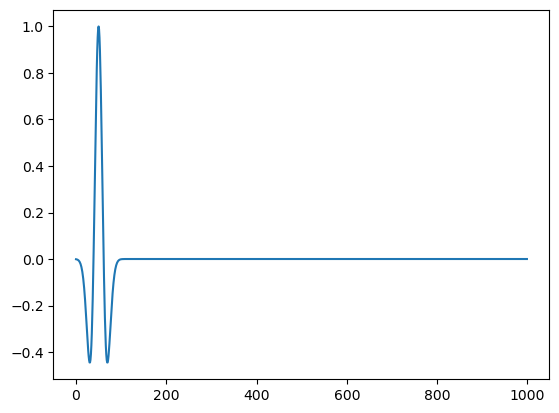

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7cf8f2911090>

In [13]:
plot(source_ricker(10,0.1,t))